# B2B Pricing Intelligence: commercial pricing diagnostics
Identify unusual B2B customer pricing patterns that should be commercially reviewed. A flagged case does not establish that a price should increase.

Run all cells to reuse an existing cleaned df or load the official UCI dataset with the original cleaning rules. Existing customer anonymisation is preserved.

The work distinguishes **descriptive analysis**, **diagnostic screening**, **exploratory modelling** and **commercial scenario analysis**.
Source: Chen, D. (2012), Online Retail II, UCI Machine Learning Repository, https://doi.org/10.24432/C5CG6D (CC BY 4.0).


In [1]:
from pathlib import Path
import json
import sys
import pandas as pd
import numpy as np
from IPython.display import display

analysis_dir = Path.cwd() if (Path.cwd() / 'export_dashboard.py').exists() else Path.cwd() / 'pricinganalysis'
sys.path.insert(0, str(analysis_dir.resolve()))
from export_dashboard import export_dashboard, DEFAULT_OUTPUT, unpack_records, unpack_records, unpack_records
if 'df' not in globals():
    from load_uci import load_cleaned_uci
    df = load_cleaned_uci()
from load_uci import clean_product_master
df = clean_product_master(df)
print(f'Loaded {len(df):,} cleaned rows')


Loaded 1,037,020 cleaned rows


## 1. Descriptive analysis: data validation
Inspect date coverage, missing customer identity and extreme positive transactions before interpreting pricing. The exporter validates cleaned-data assumptions and preserves merchandise extremes and exact duplicates. StockCode is trimmed and uppercased as the product identifier. Audited non-merchandise codes are excluded using the explicit list and reasons in load_uci.py. Each SKU uses its most frequent nonempty, whitespace-normalized description, with alphabetical tie-breaking. Missing-customer revenue remains in overall data-quality totals but is excluded from the executive Total Identified Revenue KPI and customer comparisons.


In [2]:
display(df[['Quantity', 'UnitPrice', 'Revenue']].describe().T)
display(df.nlargest(10, 'Quantity')[['StockCode','Quantity','UnitPrice','Revenue']])
price_column = 'UnitPrice' if 'UnitPrice' in df else 'Price'
display(df.nlargest(10, price_column)[['StockCode','Quantity',price_column,'Revenue']])


,count,mean,std,min,25%,50%,75%,max
Quantity,1037020.0,10.995612,126.775268,1.000,1.00,3.00,11.00,80995.00
UnitPrice,1037020.0,3.339331,4.734675,0.001,1.25,2.10,4.13,1157.15
Revenue,1037020.0,19.392198,197.024558,0.001,3.90,9.96,17.70,168469.60


,StockCode,Quantity,UnitPrice,Revenue
1065882,23843,80995,2.08,168469.6
587080,23166,74215,1.04,77183.6
90857,37410,19152,0.10,1915.2
127166,21099,12960,0.10,1296.0
127168,21091,12960,0.10,1296.0
127169,21085,12744,0.10,1274.4
127167,21092,12480,0.10,1248.0
135027,21984,10000,0.25,2500.0
135028,21982,10000,0.25,2500.0
135029,21980,10000,0.25,2500.0


,StockCode,Quantity,UnitPrice,Revenue
192196,84016,1,1157.15,1157.15
136403,84016,1,867.79,867.79
748132,22502,60,649.50,38970.00
748143,22502,1,649.50,649.50
180997,84016,1,408.40,408.40
268525,22656,1,295.00,295.00
268526,22655,1,295.00,295.00
268766,22655,1,295.00,295.00
270553,22656,1,295.00,295.00
272236,22656,1,295.00,295.00


## 2. Descriptive analysis and diagnostic screening: export aggregates
Weighted effective price = revenue / quantity. The benchmark is the median customer effective price within a SKU. Price gap = (benchmark - effective price) / benchmark. Customers retain public-facing aliases.

The default 15% gap is a **configurable screening threshold**, not an economically proven optimal threshold. Set `gap_threshold` below to adjust it. Evidence still requires 10 SKU customers, 30 SKU orders and 3 customer-SKU orders.

- **Pricing Review:** material below-median price and quantity at or below the SKU customer median. Review whether commercial terms justify the difference.
- **Possible Volume Justification:** material below-median price and above-median quantity. Higher volume may justify the discount; review commercial terms before changing price.
- **Maintain / No Material Gap:** no material gap under this screening rule.
- **Insufficient Evidence:** minimum evidence controls are not met.

Historical data alone cannot prove a price should increase. Model coefficients, proposed price changes and confidence labels do not determine these classifications.


In [3]:
gap_threshold = 0.15  # Configurable screening choice, not an optimal threshold.
metadata = export_dashboard(df, gap_threshold=gap_threshold)
display(pd.Series(metadata, name='Data quality / executive overview'))
def read_export(name):
    return pd.DataFrame(unpack_records(json.loads((DEFAULT_OUTPUT / f'{name}.json').read_text(encoding='utf-8'))))
customer_summary = read_export('customer_summary')
sku_pricing = read_export('sku_pricing')
pricing_opportunities = read_export('pricing_opportunities')
elasticity = read_export('elasticity')
scenario = read_export('scenario')


Exported 5,852 customers, 4,621 SKUs, 480,988 customer-SKU aggregates to C:\Users\Haniy Turana\Desktop\dashboard\sale analysis\dataanalysisdiysaleperformance\portfolio-security-review\projects\b2b-pricing-intelligence\data


date_start                    2009-12-01
date_end                      2011-12-09
rows                             1037020
orders                             39516
total_revenue               20110097.687
missing_customer_rows             234369
missing_customer_revenue      2675632.94
quantity_p999                    489.886
price_p999                         34.95
max_quantity                       80995
max_price                        1157.15
status                             ready
customers                           5852
skus                                4621
identified_revenue          17434464.747
relationships_reviewed            480988
pricing_review_cases                  72
possible_volume_cases               2428
gap_threshold                       0.15
elasticity_available                True
Name: Data quality / executive overview, dtype: object

## 3. Descriptive analysis: customer profile
Small, Medium, Large and Strategic are descriptive groups based primarily on revenue percentile, not actual contractual customer tiers. Small is below 50%, Medium 50-80%, Large at least 80%, and Strategic at least 95% with five orders. Order frequency is orders per observed active month (minimum one month); recency is relative to the last dataset date.


In [4]:
display(customer_summary.head(20))
display(customer_summary.groupby('segment').agg(customers=('CustomerID','count'), revenue=('revenue','sum'), orders=('orders','sum'), quantity=('quantity','sum')))

,CustomerID,revenue,quantity,orders,skus,aov,units_per_order,recency_days,orders_per_month,segment
0,C00001,77352.96,74239,3,25,25784.320000,24746.333333,325,0.283579,Large
1,C00002,5633.32,3286,8,126,704.165000,410.750000,1,0.604218,Large
2,C00003,1658.40,2704,5,24,331.680000,540.800000,74,0.419249,Medium
3,C00004,3678.69,1621,3,137,1226.230000,540.333333,18,0.159917,Large
4,C00005,294.40,196,1,16,294.400000,196.000000,309,1.000000,Small
5,C00006,300.93,261,1,21,300.930000,261.000000,374,1.000000,Small
6,C00007,1729.54,714,9,68,192.171111,79.333333,35,0.767332,Medium
7,C00008,406.76,212,2,23,203.380000,106.000000,203,0.296951,Small
8,C00009,1079.40,530,1,58,1079.400000,530.000000,231,1.000000,Medium
9,C00010,947.61,543,2,35,473.805000,271.500000,213,0.171963,Medium


,customers,revenue,orders,quantity
segment,,,,
Large,889,4815956.077,10978,2896573
Medium,1756,2851979.264,9230,1753840
Small,2925,1126412.782,5508,692234
Strategic,282,8640116.624,10878,5347800


## 4. Descriptive analysis: SKU-customer pricing and dispersion
Effective price is period revenue / quantity. Latest price is the latest transaction price and may reflect a different order quantity. Price spread = (maximum customer effective price - minimum) / median customer effective price. The same SKU does not establish comparable contracts, rebates or service terms.


In [5]:
display(pricing_opportunities.head(20))
display(sku_pricing.loc[sku_pricing.eligible].sort_values('spread', ascending=False).head(20))

,CustomerID,StockCode,quantity,revenue,orders,price,order_quantity,latest_price,segment,Description,benchmark,eligible,gap,sku_median_quantity,volume_position,review_status,reason
0,C00001,15056BL,1,5.95,1,5.95,1.0,5.95,Large,EDWARDIAN PARASOL BLACK,5.950000,True,0.000000,3.0,At or below SKU customer median,Insufficient Evidence,"Fewer than 10 SKU customers, 30 SKU orders, or..."
1,C00001,15056N,1,5.95,1,5.95,1.0,5.95,Large,EDWARDIAN PARASOL NATURAL,5.950000,True,0.000000,3.0,At or below SKU customer median,Insufficient Evidence,"Fewer than 10 SKU customers, 30 SKU orders, or..."
2,C00001,15056P,1,5.95,1,5.95,1.0,5.95,Large,EDWARDIAN PARASOL PINK,5.950000,True,0.000000,3.0,At or below SKU customer median,Insufficient Evidence,"Fewer than 10 SKU customers, 30 SKU orders, or..."
3,C00001,20679,1,5.95,1,5.95,1.0,5.95,Large,EDWARDIAN PARASOL RED,5.950000,True,0.000000,3.0,At or below SKU customer median,Insufficient Evidence,"Fewer than 10 SKU customers, 30 SKU orders, or..."
4,C00001,20682,1,3.25,1,3.25,1.0,3.25,Large,RED RETROSPOT CHILDRENS UMBRELLA,3.250000,True,0.000000,6.0,At or below SKU customer median,Insufficient Evidence,"Fewer than 10 SKU customers, 30 SKU orders, or..."
5,C00001,20685,1,7.49,1,7.49,1.0,7.49,Large,DOORMAT RED RETROSPOT,7.665303,True,0.022870,3.0,At or below SKU customer median,Insufficient Evidence,"Fewer than 10 SKU customers, 30 SKU orders, or..."
6,C00001,21523,1,7.49,1,7.49,1.0,7.49,Large,DOORMAT FANCY FONT HOME SWEET HOME,7.643333,True,0.020061,2.0,At or below SKU customer median,Insufficient Evidence,"Fewer than 10 SKU customers, 30 SKU orders, or..."
7,C00001,21524,1,7.49,1,7.49,1.0,7.49,Large,DOORMAT SPOTTY HOME SWEET HOME,7.720000,True,0.029793,2.0,At or below SKU customer median,Insufficient Evidence,"Fewer than 10 SKU customers, 30 SKU orders, or..."
8,C00001,21955,1,7.49,1,7.49,1.0,7.49,Large,DOORMAT UNION JACK GUNS AND ROSES,7.490000,True,0.000000,2.0,At or below SKU customer median,Insufficient Evidence,"Fewer than 10 SKU customers, 30 SKU orders, or..."
9,C00001,22365,1,7.49,1,7.49,1.0,7.49,Large,DOORMAT RESPECTABLE HOUSE,7.490000,True,0.000000,2.0,At or below SKU customer median,Insufficient Evidence,"Fewer than 10 SKU customers, 30 SKU orders, or..."


,StockCode,customers,benchmark,minimum,maximum,quantity,revenue,transactions,orders,Description,weighted_price,spread,eligible
1683,22502,335,5.78,3.125,329.88843,3128,55017.60,595,568,PICNIC BASKET WICKER SMALL,17.588747,56.533465,True
2965,40016,133,0.42,0.250,8.29000,15559,5069.48,203,196,CHINESE DRAGON PAPER LANTERNS,0.325823,19.142857,True
4036,85071C,85,0.39,0.380,4.96000,1203,685.12,100,98,"CHARLIE+LOLA""EXTREMELY BUSY"" SIGN",0.569510,11.743590,True
3633,84660A,34,0.79,0.790,7.46000,851,814.40,42,42,WHITE STITCHED WALL CLOCK,0.956992,8.443038,True
524,21114,359,1.25,1.060,10.79000,5707,7065.43,488,460,LAVENDER SCENTED FABRIC HEART,1.238029,7.784000,True
4039,85078,63,0.19,0.190,1.63000,2068,585.80,87,84,SCANDINAVIAN 3 HEARTS NAPKIN RING,0.283269,7.578947,True
1785,22609,118,0.19,0.190,1.63000,6830,2234.78,155,152,PENS ASSORTED SPACEBALL,0.327201,7.578947,True
3864,84926D,29,0.29,0.290,2.46000,766,342.89,41,38,LA PALMIERA TILE COASTER,0.447637,7.482759,True
3865,84926E,40,0.29,0.290,2.46000,1104,472.34,50,48,FLOWERS TILE COASTER,0.427844,7.482759,True
3866,84926F,24,0.29,0.290,2.46000,466,231.75,31,30,PSYCHEDELIC TILE COASTER,0.497318,7.482759,True


## 5. Diagnostic screening: volume versus effective price
Compare customers within a SKU. The customer's total quantity is compared with the SKU customer median quantity. Volume position offers a possible explanation, not proof of a negotiated discount. Contracts, rebates and negotiated pricing reasons are unavailable.


In [6]:
display(pricing_opportunities[['StockCode','CustomerID','segment','orders','quantity','sku_median_quantity','volume_position','order_quantity','price']].head(30))

,StockCode,CustomerID,segment,orders,quantity,sku_median_quantity,volume_position,order_quantity,price
0,15056BL,C00001,Large,1,1,3.0,At or below SKU customer median,1.0,5.95
1,15056N,C00001,Large,1,1,3.0,At or below SKU customer median,1.0,5.95
2,15056P,C00001,Large,1,1,3.0,At or below SKU customer median,1.0,5.95
3,20679,C00001,Large,1,1,3.0,At or below SKU customer median,1.0,5.95
4,20682,C00001,Large,1,1,6.0,At or below SKU customer median,1.0,3.25
5,20685,C00001,Large,1,1,3.0,At or below SKU customer median,1.0,7.49
6,21523,C00001,Large,1,1,2.0,At or below SKU customer median,1.0,7.49
7,21524,C00001,Large,1,1,2.0,At or below SKU customer median,1.0,7.49
8,21955,C00001,Large,1,1,2.0,At or below SKU customer median,1.0,7.49
9,22365,C00001,Large,1,1,2.0,At or below SKU customer median,1.0,7.49


## 6. Exploratory modelling: historical price response
Monthly log(quantity) = intercept + beta * log(effective price). At least 12 observed months, four distinct prices and 5% price and quantity variation are required. All estimated fits are retained here; only fits satisfying the sensitivity filters appear in the dashboard.

Hypothetical sensitivity additionally requires -3 <= beta < 0, p < .05 and R-squared >= .20. These exploratory filters and unadjusted p-values do not establish causality. Seasonality, inventory availability and customer mix are uncontrolled. Promotions and contracts are unavailable. Association does not prove price caused demand changes. Missing months are not assumed to be zero demand and partial months can bias estimates.

Hypothetical quantity = historical quantity * price ratio ** beta. This evaluates sensitivity across the observed historical period, not forecast revenue or a recommended price. No coefficient is joined to customer review statuses, and no automatic customer price increase or revenue opportunity is calculated.


In [7]:
display(elasticity.drop(columns=['points'], errors='ignore'))
display(scenario.head(25))

,StockCode,beta,pvalue,r2,n,eligible,interpretation
0,10002,-14.034893,0.000701,0.546090,17,False,"Exploratory monthly association; seasonality, ..."
1,10123C,-2.038515,0.013660,0.409827,14,True,"Exploratory monthly association; seasonality, ..."
2,10125,-1.552215,0.138438,0.106414,22,False,"Exploratory monthly association; seasonality, ..."
3,10133,-2.564267,0.000008,0.638468,22,True,"Exploratory monthly association; seasonality, ..."
4,10135,-2.189346,0.005145,0.293618,25,True,"Exploratory monthly association; seasonality, ..."
...,...,...,...,...,...,...,...
1209,90086,-1.651493,0.048976,0.334183,12,True,"Exploratory monthly association; seasonality, ..."
1210,90093,-1.557486,0.079438,0.275975,12,False,"Exploratory monthly association; seasonality, ..."
1211,90167,-13.844973,0.008372,0.517367,12,False,"Exploratory monthly association; seasonality, ..."
1212,90209C,-12.689542,0.000457,0.654575,14,False,"Exploratory monthly association; seasonality, ..."


,StockCode,change,price,quantity,revenue,impact
0,10123C,-0.05,0.344766,701.661813,241.909012,12.549012
1,10123C,0.00,0.362911,632.000000,229.360000,0.000000
2,10123C,0.03,0.373799,595.042799,222.426245,-6.933755
3,10123C,0.05,0.381057,572.166433,218.028003,-11.331997
4,10123C,0.10,0.399203,520.400220,207.745085,-21.614915
5,10133,-0.05,0.550966,3822.056011,2105.822837,162.362837
6,10133,0.00,0.579964,3351.000000,1943.460000,0.000000
7,10133,0.03,0.597363,3106.392712,1855.644429,-87.815571
8,10133,0.05,0.608962,2956.918890,1800.652421,-142.807579
9,10133,0.10,0.637961,2624.415170,1674.273499,-269.186501


## 7. Diagnostic screening: relationships for commercial review
Sort cases by price gap to aid investigation. A large gap is a diagnostic signal, not a monetary opportunity. Review commercial terms, service requirements and purchasing behaviour before changing price.


In [8]:
display(pricing_opportunities['review_status'].value_counts())
review_cases = pricing_opportunities.loc[pricing_opportunities.review_status.eq('Pricing Review')]
display(review_cases.sort_values('gap', ascending=False)[['CustomerID','StockCode','Description','segment','orders','quantity','price','latest_price','benchmark','gap','volume_position','review_status','reason']].head(20))
print('Pricing Review cases:', metadata['pricing_review_cases'])
print('Possible Volume Justification cases:', metadata['possible_volume_cases'])


Pricing Review cases: 72
Possible Volume Justification cases: 2428


review_status
Insufficient Evidence            426112
Maintain / No Material Gap        52376
Possible Volume Justification      2428
Pricing Review                       72
Name: count, dtype: int64

,CustomerID,StockCode,Description,segment,orders,quantity,price,latest_price,benchmark,gap,volume_position,review_status,reason
471211,C05683,22066,LOVE HEART TRINKET POT,Large,3,6,0.390000,0.39,1.45,0.731034,At or below SKU customer median,Pricing Review,Effective price meets the 15% below-median scr...
448536,C05409,21162,TOXIC AREA DOOR HANGER,Strategic,3,3,0.390000,0.39,1.45,0.731034,At or below SKU customer median,Pricing Review,Effective price meets the 15% below-median scr...
315336,C03834,22091,EMPIRE TISSUE BOX,Large,3,4,0.390000,0.39,1.25,0.688000,At or below SKU customer median,Pricing Review,Effective price meets the 15% below-median scr...
162852,C02049,21811,HANGING HEART WITH BELL,Medium,3,12,0.390000,0.39,1.25,0.688000,At or below SKU customer median,Pricing Review,Effective price meets the 15% below-median scr...
315344,C03834,22099,CARAVAN SQUARE TISSUE BOX,Large,3,4,0.390000,0.39,1.25,0.688000,At or below SKU customer median,Pricing Review,Effective price meets the 15% below-median scr...
174237,C02151,22065,CHRISTMAS PUDDING TRINKET POT,Large,3,12,0.566667,0.39,1.45,0.609195,At or below SKU customer median,Pricing Review,Effective price meets the 15% below-median scr...
387910,C04707,22398,MAGNETS PACK OF 4 SWALLOWS,Medium,4,7,0.512857,0.39,1.25,0.589714,At or below SKU customer median,Pricing Review,Effective price meets the 15% below-median scr...
162902,C02049,22342,HOME GARLAND PAINTED ZINC,Medium,3,10,0.750000,0.75,1.65,0.545455,At or below SKU customer median,Pricing Review,Effective price meets the 15% below-median scr...
356656,C04351,21819,GLITTER CHRISTMAS STAR,Medium,4,9,0.390000,0.39,0.85,0.541176,At or below SKU customer median,Pricing Review,Effective price meets the 15% below-median scr...
360608,C04381,21179,NO JUNK MAIL METAL SIGN,Medium,4,9,0.581111,0.39,1.25,0.535111,At or below SKU customer median,Pricing Review,Effective price meets the 15% below-median scr...


## 8. Optional portfolio charts
Requires matplotlib. Charts use the same exported aggregates as the website.

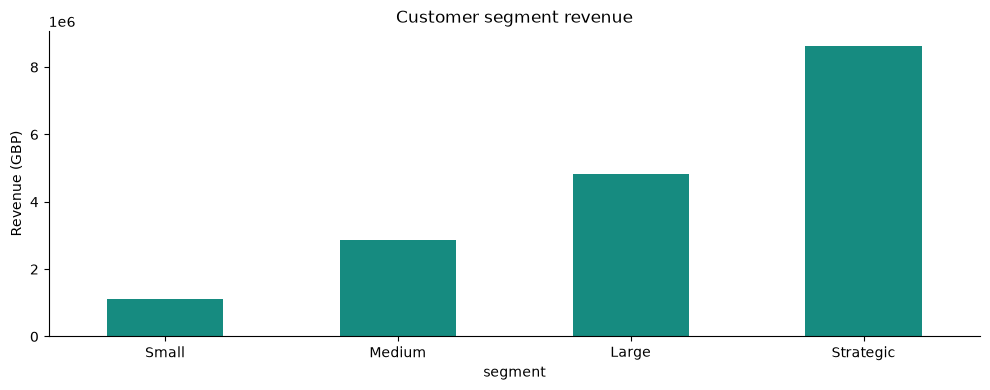

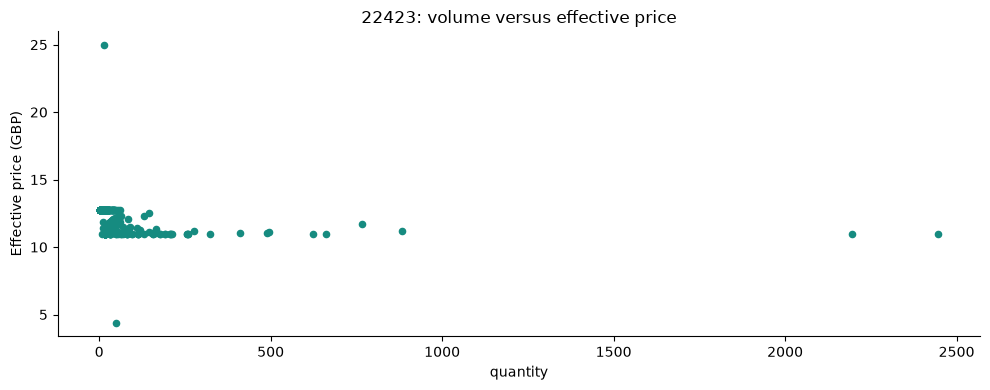

In [9]:
import matplotlib.pyplot as plt
plt.rcParams.update({'figure.figsize': (10, 4), 'axes.spines.top': False, 'axes.spines.right': False})
customer_summary.groupby('segment').revenue.sum().reindex(['Small','Medium','Large','Strategic']).plot.bar(color='#168b80', ylabel='Revenue (GBP)', title='Customer segment revenue', rot=0)
plt.tight_layout(); plt.show()
eligible_skus = sku_pricing.loc[sku_pricing.eligible].sort_values('revenue', ascending=False)
if not eligible_skus.empty:
    selected = eligible_skus.iloc[0].StockCode
    points = pricing_opportunities.loc[pricing_opportunities.StockCode.eq(selected)]
    points.plot.scatter(x='quantity', y='price', color='#168b80', title=f'{selected}: volume versus effective price')
    plt.ylabel('Effective price (GBP)'); plt.tight_layout(); plt.show()


## 9. Commercial scenario analysis and publication
The separate JavaScript Commercial Pricing Simulator asks: if actual commercial inputs are available, what price supports the selected margin? Inputs are user-defined, not derived from UCI.

Expected warranty cost = claim probability * average claim cost. Cost to serve = product cost + expected warranty cost + additional service cost. Required price = cost to serve / (1 - target gross margin). Gross profit = selling price - cost to serve; gross margin = gross profit / selling price. The user must confirm that positive claim probability covers the entered warranty period; duration alone does not multiply cost.

Run the exporter and commit the static dashboard and aggregates at `projects/b2b-pricing-intelligence/`. No Python backend is required.

### Limitations
The dataset lacks product cost, contracts, rebates, competitor prices, warranty terms, service cost and negotiated pricing reasons. Purchasing accounts are not verified B2B entities. Use historical transaction data to identify unusual pricing relationships for commercial review, then use actual commercial inputs separately to evaluate financially sustainable pricing. Do not publish original customer IDs or raw transactions.
